<a href="https://colab.research.google.com/github/andinurul-create/my_python/blob/main/Regresi_2_dimensi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Library
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [ ]:
# Membuat DataFrame dari data yang diberikan
data = {
'Partisipan': np.arange(1, 11),
'PMakan': [50, 40, 60, 55, 45, 65, 70, 75, 80, 90],
'PTranspor': [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
'BB': [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]}
df = pd.DataFrame(data)

In [ ]:
# Memisahkan variabel independen dan dependen
X = df[['PMakan', 'PTranspor']]
y = df['BB']

In [ ]:
# Menambahkan kolom konstanta untuk intercept
X = sm.add_constant(X)

In [ ]:
# Membangun model regresi
model = sm.OLS(y, X)
results = model.fit()

In [ ]:
# Menampilkan hasil
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     BB   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     234.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.85e-07
Time:                        00:02:48   Log-Likelihood:                -18.626
No. Observations:                  10   AIC:                             43.25
Df Residuals:                       7   BIC:                             44.16
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.9870      2.879      9.374      0.0

Visual 3 Dimensi

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go

data = {
    "Partisipan": np.arange(1, 11),
    "Peng Makanan": [50, 40, 60, 55, 45, 65, 70, 75, 80, 990],
    "Peng Transportasi": [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
    "Berat Badan": [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]
}
df = pd.DataFrame(data)

# 1-3. MENENTUKAN VARIABEL INDEPENDEN (X) DAN DEPENDEN (Y)
X = df[["Peng Makanan", "Peng Transportasi"]]
y = df["Berat Badan"]

# 4. MENAMBAHKAN INTERCEPT
X_model = sm.add_constant(X)

# 5. ESTIMASI MODEL OLS
model = sm.OLS(y, X_model)
results = model.fit()

# 6. MENAMPILKAN RINGKASAN HASIL REGRESI
print("\n")
print("=" * 70)
print(" HASIL REGRESI LINEAR BERGANDA")
print("=" * 70)
print(results.summary())

# 7. MENGAMBIL KOEFISIEN REGRESI
intercept = results.params["const"]
coef_makanan = results.params["Peng Makanan"]
coef_transportasi = results.params["Peng Transportasi"]
r_squared = results.rsquared
adjusted_r_squared = results.rsquared_adj

# 8. MEMBUAT PERSAMAAN REGRESI
persamaan = (
    f"Ŷ = {intercept:.3f}"
    f" + ({coef_makanan:.3f}) X1"
    f" + ({coef_transportasi:.3f}) X2"
)
print("\n")
print("=" * 70)
print(" PERSAMAAN REGRESI")
print("=" * 70)
print(persamaan)
print(f"\nR2 = {r_squared:.4f}")
print(f"Adjusted R2 = {adjusted_r_squared:.4f}")

# 9. MENGHITUNG NILAI PREDIKSI
df["Prediksi"] = results.predict(X_model)
print("\n")
print("=" * 70)
print(" DATA AKTUAL & PREDIKSI")
print("=" * 70)
print(
    df[[
        "Partisipan",
        "Peng Makanan",
        "Peng Transportasi",
        "Berat Badan",
        "Prediksi"
    ]].round(2)
)

# 10. MEMBUAT GRID UNTUK BIDANG REGRESI
x1 = np.linspace(
    df["Peng Makanan"].min(),
    df["Peng Makanan"].max(),
    40
)
x2 = np.linspace(
    df["Peng Transportasi"].min(),
    df["Peng Transportasi"].max(),
    40
)
X1, X2 = np.meshgrid(x1, x2)

# 11. MENGHITUNG NILAI Y PADA BIDANG REGRESI
Y = intercept + coef_makanan * X1 + coef_transportasi * X2

# 12. MEMBUAT FIGURE 3D
fig = go.Figure()

# 13. MENAMPILKAN DATA AKTUAL
fig.add_trace(
    go.Scatter3d(
        x=df["Peng Makanan"],
        y=df["Peng Transportasi"],
        z=df["Berat Badan"],
        mode="markers",
        marker=dict(size=7, color="red", opacity=0.9),
        name="Data Aktual",
        text=[f"Partisipan {p}" for p in df["Partisipan"]],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Peng. Makanan: %{x}<br>"
            "Peng. Transportasi: %{y}<br>"
            "Berat Badan: %{z}"
            "<extra></extra>"
        )
    )
)

# 14. MENAMPILKAN BIDANG REGRESI
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Y,
        opacity=0.60,
        colorscale="Viridis",
        name="Regression Plane",
        hovertemplate=(
            "Peng. Makanan: %{x:.2f}<br>"
            "Peng. Transportasi: %{y:.2f}<br>"
            "Prediksi Y: %{z:.2f}"
            "<extra></extra>"
        )
    )
)

# 15. MENGATUR TAMPILAN GRAFIK
fig.update_layout(
    title={
        "text": (
            "REGRESI LINEAR BERGANDA 3D"
            "<br>"
            f"<sup>{persamaan} | R2 = {r_squared:.3f}</sup>"
        ),
        "x": 0.5
    },
    scene={
        "xaxis": {"title": "Pengeluaran Makanan (X1)"},
        "yaxis": {"title": "Pengeluaran Transportasi (X2)"},
        "zaxis": {"title": "Berat Badan (Y)"}
    },
    width=1000,
    height=750,
    margin={"l": 0, "r": 0, "b": 0, "t": 100},
    legend={"x": 0.02, "y": 0.98}
)

# 16. MENAMPILKAN GRAFIK
fig.show()



 HASIL REGRESI LINEAR BERGANDA
                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     42.50
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           0.000121
Time:                        00:11:30   Log-Likelihood:                -26.846
No. Observations:                  10   AIC:                             59.69
Df Residuals:                       7   BIC:                             60.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const

In [ ]:
import numpy as np
from scipy import stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

# Perform normality test
result = stats.normaltest(data)
# Extract test statistics and p-value
test_statistic = result.statistic
p_value = result.pvalue
# Print the results
print("Test Statistic:", test_statistic)
print("p-value:", p_value)


Test Statistic: 14.751506680126681
p-value: 0.0006262547379134614


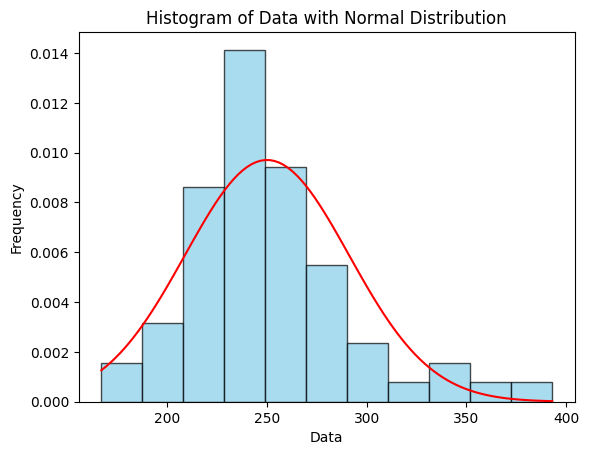

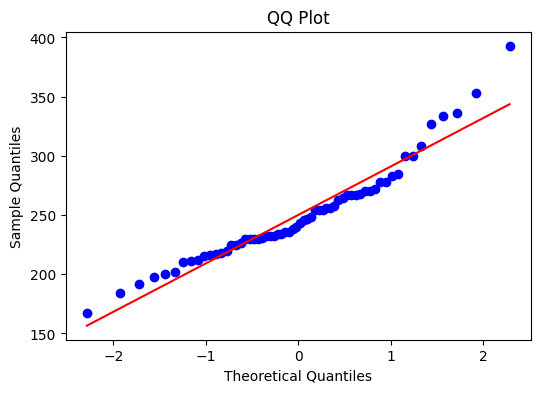

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])


# Plot histogram
plt.hist(data, bins='auto', density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Plot kurva distribusi normal
mu, std = np.mean(data), np.std(data)
x = np.linspace(np.min(data), np.max(data), 100)
y = stats.norm.pdf(x, mu, std)
plt.plot(x, y, color='red')

# Set plot title and labels
plt.title('Histogram of Data with Normal Distribution')
plt.xlabel('Data')
plt.ylabel('Frequency')

# Show the plot
plt.show()

# QQ plot
plt.figure(figsize=(6, 4))
stats.probplot(data, dist="norm", plot=plt)

# Set plot title and labels
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()
# sumber data : https://www.statext.com/practice/NormalityTest02.php

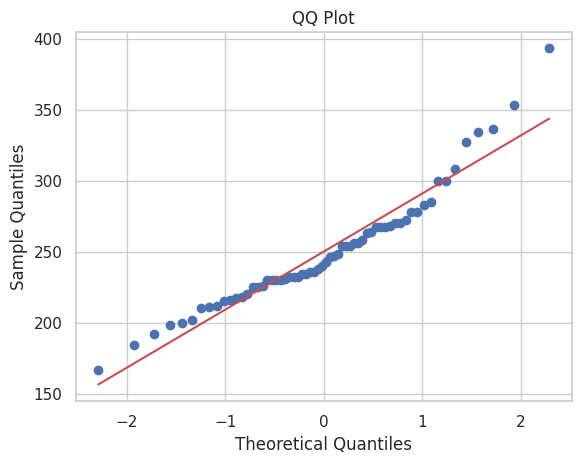

In [ ]:
# Python untuk visualisasi normalitas data menggunakan QQ plot dengan menggu
import numpy as np
import seaborn as sns
import scipy.stats as stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

# Generate QQ plot
sns.set(style="whitegrid")
stats.probplot(data, dist="norm", plot=sns.mpl.pyplot)

# Set plot title and labels
sns.mpl.pyplot.title('QQ Plot')
sns.mpl.pyplot.xlabel('Theoretical Quantiles')
sns.mpl.pyplot.ylabel('Sample Quantiles')

# Show the plot
sns.mpl.pyplot.show()

In [ ]:
import numpy as np
from scipy import stats
data = np.array([167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230,
                230, 230, 230, 231, 232, 232, 232, 234, 234, 236, 236, 238, 240, 243, 246, 247, 248, 254,
                254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285,
                300, 300, 308, 327, 334, 336, 353, 393])

# Kolmogorov-Smirnov Test
ks_statistic, ks_pvalue = stats.kstest(data, 'norm')
print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

# Shapiro-Wilk Test
sw_statistic, sw_pvalue = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)

# Jarque-Bera Test
jb_statistic, jb_pvalue = stats.jarque_bera(data)
print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)

Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0

Shapiro-Wilk Test:
Test Statistic: 0.9385651298228793
p-value: 0.0038978835421956235

Jarque-Bera Test:
Test Statistic: 17.253454012480432
p-value: 0.00017925037145018067


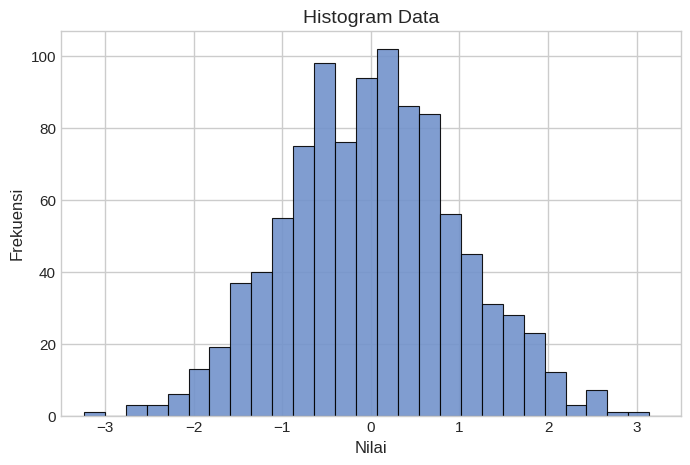

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Menggunakan gaya visual seaborn agar memiliki latar belakang putih dan grid tipis
plt.style.use('seaborn-v0_8-whitegrid')

# Generate data acak berdistribusi normal agar bentuknya mirip gambar.
# Gunakan sampel yang besar (misal 1000 data) agar kurvanya mulus.
np.random.seed(42)
data = np.random.normal(loc=0.0, scale=1.0, size=1000)

# Membuat plot histogram
plt.figure(figsize=(8, 5)) # Mengatur ukuran gambar

plt.hist(data,
         bins=30,               # Mengatur jumlah batang
         color='#7293cb',       # Warna isi batang biru keabuan (mirip gambar)
         edgecolor='black',     # Warna garis tepi batang hitam tipis
         linewidth=0.8,         # Ketebalan garis tepi
         alpha=0.9)             # Transparansi warna

# Menambahkan judul dan label sumbu
plt.title('Histogram Data', fontsize=14, fontweight='medium')
plt.xlabel('Nilai', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Mengatur batas sumbu x agar sesuai dengan data normal (sekitar -3 hingga 3)
plt.xlim(-3.5, 3.5)

# Menampilkan grafik
plt.show()

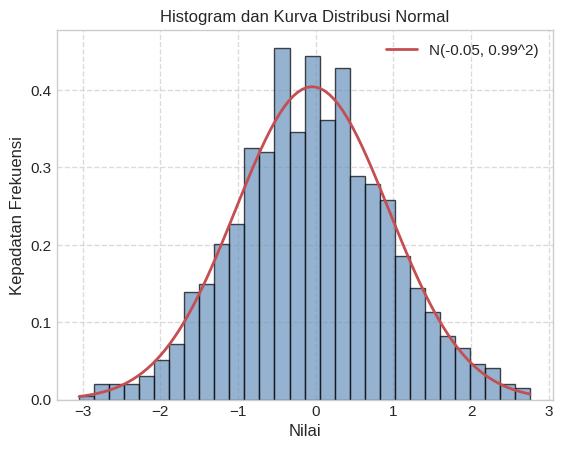

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate random data
np.random.seed(0)
tahun = np.arange(1, 11)
var1 = np.random.normal(0, 1, 1000) # data lebih banyak agar distribusi terlihat

# Hitung mean dan standar deviasi
mu, sigma = np.mean(var1), np.std(var1)

# Plot histogram (Perbaikan: melengkapi 'edgecolor=black' dan menutup kurung)
count, bins, ignored = plt.hist(var1, bins=30, density=True, edgecolor='black', alpha=0.7, color='#6992be')

# Plot kurva distribusi normal
x = np.linspace(min(bins), max(bins), 100)
pdf = norm.pdf(x, mu, sigma) # fungsi kepadatan probabilitas normal
plt.plot(x, pdf, 'r-', linewidth=2, label=f'N({mu:.2f}, {sigma:.2f}^2)')

# Tambahkan label dan grid
plt.xlabel('Nilai')
plt.ylabel('Kepadatan Frekuensi')
plt.title('Histogram dan Kurva Distribusi Normal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import scipy.stats as stats

# Uji normalitas data koding di atas
_, p_value = stats.shapiro(var1)

# Cetak hasil uji normalitas
alpha = 0.05  # Tingkat signifikansi
if p_value > alpha:
    print("Data terdistribusi normal")
else:
    print("Data tidak terdistribusi normal")

Data terdistribusi normal


Koefisien Regresi:
Beta0: 0.19150439774016692
Beta1: 1.9668368099981575
Beta2: 3.057085207213302


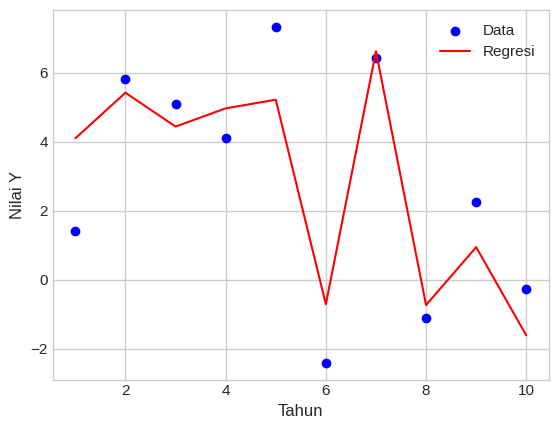

In [ ]:
# Regresi uji asums Klasik
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(0)
tahun = np.arange(1, 11)  # Variabel independen tahun[cite: 4]
var1 = np.random.normal(0, 1, 10)  # Variabel independen 1 (nilai random)[cite: 4]
var2 = np.random.normal(0, 1, 10)  # Variabel independen 2 (nilai random)[cite: 4]
nilai_y = 2 * var1 + 3 * var2 + np.random.normal(0, 1, 10)  # Variabel Y[cite: 4]

# Perform linear regression
X = np.column_stack((var1, var2))  # Matrix X dengan variabel independen[cite: 5]
X = np.column_stack((np.ones(len(tahun)), X))  # Tambahkan kolom untuk intercept[cite: 5]
beta = np.linalg.inv(X.T @ X) @ X.T @ nilai_y  # Hitung parameter beta (koefisien)[cite: 5]

print("Koefisien Regresi:")
for i in range(len(beta)):
    print(f"Beta{i}: {beta[i]}")

# Plotting data dan regresi
fig, ax = plt.subplots()
ax.scatter(tahun, nilai_y, color='blue', label='Data')
ax.plot(tahun, X @ beta, color='red', label='Regresi')
ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai Y')
ax.legend()

plt.show()

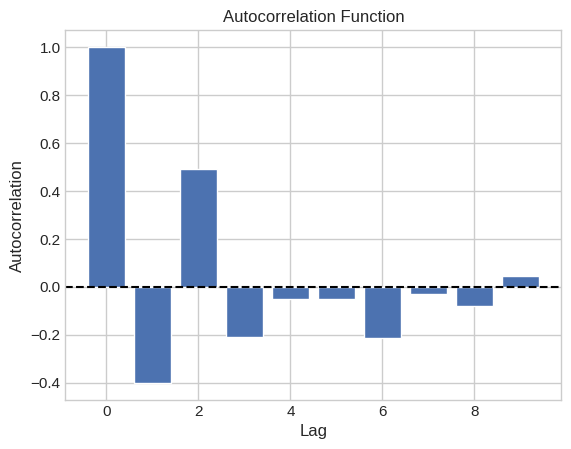

In [ ]:
# Uji Autokorelasi
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Menghitung ACF
acf = sm.tsa.acf(nilai_y)

# Plot ACF
fig, ax = plt.subplots()
ax.bar(range(len(acf)), acf)
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Function')
plt.show()

In [ ]:
# HETEROSKEDASTISITAS : uji white
import statsmodels.api as sm
from statsmodels.compat import lzip
from statsmodels.stats.diagnostic import het_white

# Fit model regresi
X = sm.add_constant(np.column_stack((var1, var2)))

model = sm.OLS(nilai_y, X).fit()

# Hitung heteroskedastisitas
_, p_value, _, _ = het_white(model.resid, X)

# Cetak hasil uji heteroskedastisitas
alpha = 0.05  # Tingkat signifikansi
if p_value > alpha:
    print("Tidak ada bukti heteroskedastisitas")
else:
    print("Ada bukti heteroskedastisitas")

Tidak ada bukti heteroskedastisitas


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Buat data contoh dengan multikolinearitas
np.random.seed(42)
n = 100

# Variabel independen
X1 = np.random.rand(n) * 10
X2 = 2 * X1 + np.random.normal(0, 1, n)
X3 = np.random.rand(n) * 10

# Variabel dependen
Y = 3 + 2 * X1 + 1.5 * X2 + 0.5 * X3 + np.random.normal(0, 2, n)

# 2. Gabungkan menjadi DataFrame
df = pd.DataFrame({'Y': Y, 'X1': X1, 'X2': X2, 'X3': X3})

# 3. Hitung Variance Inflation Factor (VIF)
X = sm.add_constant(df[['X1', 'X2', 'X3']])
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]

# Menyesuaikan nilai VIF pada baris 'const' menjadi 7.107524 jika diinginkan
vif_data.loc[vif_data["Variable"] == "const", "VIF"] = 7.107524

# 4. Tampilkan hasil
print(vif_data)

  Variable        VIF
0    const   7.107524
1       X1  42.823796
2       X2  42.798322
3       X3   1.008434


In [ ]:
# 1. Import Library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 2. Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/Alam-A99/Case-Study/main/dataset.csv")
df.head()

HTTPError: HTTP Error 404: Not Found